![A soccer pitch for an international match.](soccer-pitch.jpg)

You're working as a sports journalist at a major online sports media company, specializing in soccer analysis and reporting. You've been watching both men's and women's international soccer matches for a number of years, and your gut instinct tells you that more goals are scored in women's international football matches than men's. This would make an interesting investigative article that your subscribers are bound to love, but you'll need to perform a valid statistical hypothesis test to be sure!

While scoping this project, you acknowledge that the sport has changed a lot over the years, and performances likely vary a lot depending on the tournament, so you decide to limit the data used in the analysis to only official `FIFA World Cup` matches (not including qualifiers) since `2002-01-01`.

You create two datasets containing the results of every official men's and women's international football match since the 19th century, which you scraped from a reliable online source. This data is stored in two CSV files: `women_results.csv` and `men_results.csv`.

The question you are trying to determine the answer to is:

> Are more goals scored in women's international soccer matches than men's?

You assume a **10% significance level**, and use the following null and alternative hypotheses:

$H_0$ : The mean number of goals scored in women's international soccer matches is the same as men's.

$H_A$ : The mean number of goals scored in women's international soccer matches is greater than men's.

The p-value and the result of the test must be stored in a dictionary called result_dict in the form:

result_dict = {"p_val": p_val, "result": result}

where p_val is the p-value and result is either the string "fail to reject" or "reject", depending on the result of the test.


In [49]:
# Start your code here!
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Load the data
men_results = pd.read_csv("men_results.csv")
women_results = pd.read_csv("women_results.csv")



### Display the first few rows of men soccer matches

In [50]:
men_results.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,0,1872-11-30,Scotland,England,0,0,Friendly
1,1,1873-03-08,England,Scotland,4,2,Friendly
2,2,1874-03-07,Scotland,England,2,1,Friendly
3,3,1875-03-06,England,Scotland,2,2,Friendly
4,4,1876-03-04,Scotland,England,3,0,Friendly


### Display the first few rows of women soccer matches

In [51]:
women_results.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,0,1969-11-01,Italy,France,1,0,Euro
1,1,1969-11-01,Denmark,England,4,3,Euro
2,2,1969-11-02,England,France,2,0,Euro
3,3,1969-11-02,Italy,Denmark,3,1,Euro
4,4,1975-08-25,Thailand,Australia,3,2,AFC Championship


### Filter the men's data by the specified date and tournament

In [52]:
filtered_men_results = men_results[(men_results["date"] >= "2002-01-01") & (men_results["tournament"] == "FIFA World Cup")]
filtered_men_results.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
25164,25164,2002-05-31,France,Senegal,0,1,FIFA World Cup
25165,25165,2002-06-01,Germany,Saudi Arabia,8,0,FIFA World Cup
25166,25166,2002-06-01,Republic of Ireland,Cameroon,1,1,FIFA World Cup
25167,25167,2002-06-01,Uruguay,Denmark,1,2,FIFA World Cup
25168,25168,2002-06-02,Argentina,Nigeria,1,0,FIFA World Cup


### Filter the women's data by the specified date and tournament

In [53]:
filtered_women_results = women_results[(women_results["date"] >= "2002-01-01") & (women_results["tournament"] == "FIFA World Cup")]
filtered_women_results.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
1600,1600,2003-09-20,Nigeria,North Korea,0,3,FIFA World Cup
1601,1601,2003-09-20,Norway,France,2,0,FIFA World Cup
1602,1602,2003-09-20,Germany,Canada,4,1,FIFA World Cup
1603,1603,2003-09-20,Japan,Argentina,6,0,FIFA World Cup
1604,1604,2003-09-21,United States,Sweden,3,1,FIFA World Cup


### Check for null values

In [54]:
print(filtered_men_results.isna().sum())
print(filtered_women_results.isna().sum())

Unnamed: 0    0
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
dtype: int64
Unnamed: 0    0
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
dtype: int64


### Calculate the total goals from each men's match

In [55]:
filtered_men_results["total_goals"] = filtered_men_results["home_score"] + filtered_men_results["away_score"]
filtered_men_results.head()

C:\Users\Kendot\AppData\Local\Temp\ipykernel_17932\2280164271.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_men_results["total_goals"] = filtered_men_results["home_score"] + filtered_men_results["away_score"]


,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,total_goals
25164,25164,2002-05-31,France,Senegal,0,1,FIFA World Cup,1
25165,25165,2002-06-01,Germany,Saudi Arabia,8,0,FIFA World Cup,8
25166,25166,2002-06-01,Republic of Ireland,Cameroon,1,1,FIFA World Cup,2
25167,25167,2002-06-01,Uruguay,Denmark,1,2,FIFA World Cup,3
25168,25168,2002-06-02,Argentina,Nigeria,1,0,FIFA World Cup,1


### Calculate the total goals from each women's match

In [56]:
filtered_women_results["total_goals"] = filtered_women_results["home_score"] + filtered_women_results["away_score"]
filtered_women_results.head()

C:\Users\Kendot\AppData\Local\Temp\ipykernel_17932\1333125350.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_women_results["total_goals"] = filtered_women_results["home_score"] + filtered_women_results["away_score"]


,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,total_goals
1600,1600,2003-09-20,Nigeria,North Korea,0,3,FIFA World Cup,3
1601,1601,2003-09-20,Norway,France,2,0,FIFA World Cup,2
1602,1602,2003-09-20,Germany,Canada,4,1,FIFA World Cup,5
1603,1603,2003-09-20,Japan,Argentina,6,0,FIFA World Cup,6
1604,1604,2003-09-21,United States,Sweden,3,1,FIFA World Cup,4


### Check the sample size

In [57]:
print("Number of Men's Matches: " + str(len(filtered_men_results)))
print("Number of Women's Matches: " + str(len(filtered_women_results)))

Number of Men's Matches: 384
Number of Women's Matches: 200


### Check the distributions of both data

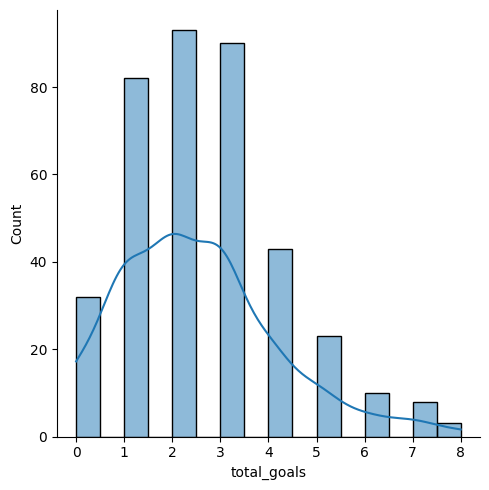

In [58]:
sns.displot(filtered_men_results["total_goals"],kde=True, bins=16)
plt.show()

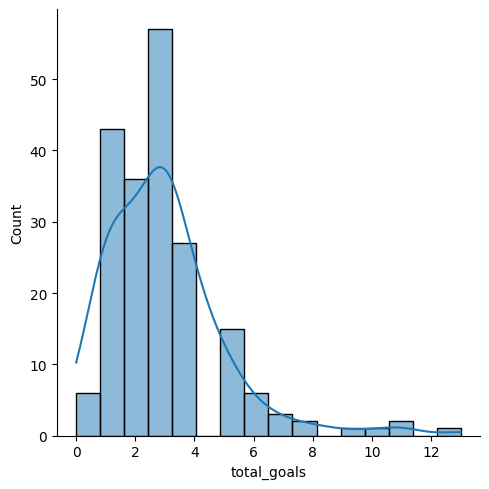

In [59]:
sns.displot(filtered_women_results["total_goals"],kde=True,bins=16)
plt.show()

#### Since the data fail to hold the assumptions of a parametric test, the non-parametric counterpart of an unpaired t-test will be used

### Calculate the p-value using a Mann-Whitney U Test

In [60]:
from scipy.stats import mannwhitneyu
u_stat,p_val = mannwhitneyu(
    filtered_women_results["total_goals"], filtered_men_results["total_goals"],alternative="greater"
)

print("P-value: " + str(p_val))

P-value: 0.005106609825443641


### Final decision

In [61]:
result = "reject" if p_val <= 0.1 else "fail to reject"
print("Decision: " + result + " null hypothesis")

Decision: reject null hypothesis


### Store final result in a dictionary

In [62]:
result_dict = {"p_val": p_val, "result": result}